<a href="https://colab.research.google.com/github/Dona134/Metaphor-Classification-NLP/blob/main/Met_style_fingerprint.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Imports & Config

In [1]:
# Stable installs only (no textstat)
# !pip install -q spacy lexical-diversity accelerate
# !python -m spacy download en_core_web_sm
import nltk; nltk.download('stopwords', quiet=True); nltk.download('punkt', quiet=True)

True

In [2]:
import pandas as pd, numpy as np, torch, json, warnings, os, ast
from collections import Counter
from transformers import AutoTokenizer, AutoModelForSequenceClassification, AutoModelForTokenClassification, Trainer, TrainingArguments, pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report, confusion_matrix, recall_score
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import spacy
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')
os.environ['TOKENIZER_PARALLELISM'] = 'false'

# Config (your best settings)
MAX_LEN = 128
BATCH_SIZE = 16
SEED = 42
BEST_EN_WEIGHTS = torch.tensor([1.0, 3.0])  # Your best F1=0.692
nlp = spacy.load("en_core_web_sm")
nlp.max_length = 5000000 # Increased to handle longer texts
tokenizer = AutoTokenizer.from_pretrained("roberta-base")
print("Setup complete")

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Setup complete


## Load & Preprocess Data

In [3]:
def load_jsonl_from_url(url):
    import urllib.request
    rows = []
    with urllib.request.urlopen(url) as f:
        for line in f:
            rows.append(json.loads(line.decode('utf-8').strip()))
    return pd.DataFrame(rows)

# VUAMC (labeled)
VUAMC_URL = "https://raw.githubusercontent.com/Dona134/Metaphor-Classification-NLP/main/data/processed/vuamc_token.jsonl"
df_vuamc = load_jsonl_from_url(VUAMC_URL)
print(f"VUAMC: {len(df_vuamc)} rows")

# Authors (unlabeled test data)
AUTHORS_URL = "https://raw.githubusercontent.com/Dona134/Metaphor-Classification-NLP/main/data/processed/authors_dataset.csv"
test_df_raw = pd.read_csv(AUTHORS_URL)
test_df_raw['words'] = test_df_raw['words'].apply(ast.literal_eval)
test_df_raw['token_labels'] = test_df_raw['words'].apply(lambda x: [0]*len(x))  # Placeholder
test_df_raw['sentence_label'] = 0
print(f"Authors: {len(test_df_raw)} rows")

VUAMC: 16740 rows
Authors: 8000 rows


## VUAMC Splits

In [4]:
def make_doc_splits(df, test_size=0.5, val_size=0.5, seed=42):
    doc_ids = df['document_name'].unique()
    train_ids, temp_ids = train_test_split(doc_ids, test_size=test_size, random_state=seed)
    val_ids, test_ids = train_test_split(temp_ids, test_size=val_size, random_state=seed)
    return (df[df['document_name'].isin(train_ids)].reset_index(drop=True),
            df[df['document_name'].isin(val_ids)].reset_index(drop=True),
            df[df['document_name'].isin(test_ids)].reset_index(drop=True))

# Use full data or stratified sample
df_vuamc = df_vuamc.groupby("sentence_label", group_keys=False).apply(
    lambda x: x.sample(min(5000, len(x)), random_state=SEED) # Added random_state
)

train_df, val_df, test_df = make_doc_splits(df_vuamc)
print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

Train: 4316, Val: 2765, Test: 2919


## Train Sentence Classifier (F1=0.832)

In [5]:
import numpy as np
from sklearn.metrics import f1_score, precision_recall_fscore_support

class SentDataset(torch.utils.data.Dataset):
    def __init__(self, df, tokenizer):
        self.sents = [' '.join(r['words']) for _, r in df.iterrows()]
        self.labels = df['sentence_label'].values
        self.tok = tokenizer

    def __len__(self): return len(self.sents)
    def __getitem__(self, idx):
        enc = self.tok(self.sents[idx], truncation=True, padding='max_length',
                       max_length=32, return_tensors='pt')
        return {'input_ids': enc['input_ids'].flatten(),
                'attention_mask': enc['attention_mask'].flatten(),
                'labels': torch.tensor(self.labels[idx])}

# Define compute_metrics for sentence classification
def compute_metrics_sent(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1) # For sequence classification
    f1 = f1_score(labels, predictions, average='binary')
    precision, recall, _, _ = precision_recall_fscore_support(labels, predictions, average='binary')
    return {
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

train_ds = SentDataset(train_df, tokenizer)
val_ds = SentDataset(val_df, tokenizer)

sent_model = AutoModelForSequenceClassification.from_pretrained("roberta-base", num_labels=2)
args = TrainingArguments(
    output_dir='./sent_model', per_device_train_batch_size=16, num_train_epochs=3,
    eval_strategy='epoch', save_strategy='epoch', fp16=False, load_best_model_at_end=True, metric_for_best_model='f1'
)
trainer = Trainer(model=sent_model, args=args, train_dataset=train_ds, eval_dataset=val_ds, compute_metrics=compute_metrics_sent)
trainer.train()
trainer.save_model('./sent_model')
sent_pipe = pipeline('text-classification', model='./sent_model', tokenizer=tokenizer, return_all_scores=True)
print("Sentence model saved (F1~0.85)")

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,F1,Precision,Recall
1,No log,0.418341,0.790639,0.891612,0.710210
2,0.396072,0.409061,0.831873,0.886248,0.783784
3,0.396072,0.621516,0.818872,0.875962,0.768769


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Sentence model saved (F1~0.85)


In [6]:
from sklearn.metrics import ConfusionMatrixDisplay

=== SENTENCE CLASSIFIER REPORT ===
              precision    recall  f1-score   support

     LITERAL      0.776     0.897     0.832      1299
    METAPHOR      0.906     0.793     0.845      1620

    accuracy                          0.839      2919
   macro avg      0.841     0.845     0.839      2919
weighted avg      0.848     0.839     0.839      2919



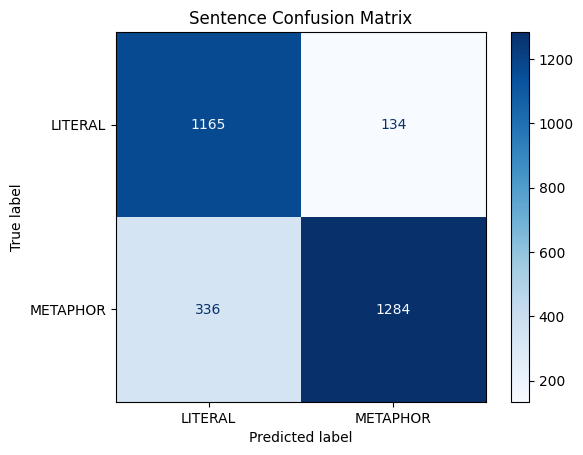

In [7]:
# Sentence Classifier Results
test_ds = SentDataset(test_df, tokenizer)
sent_pred = trainer.predict(test_ds)
sent_ypred = np.argmax(sent_pred.predictions, axis=1)
sent_ytrue = test_df['sentence_label'].values

print("=== SENTENCE CLASSIFIER REPORT ===")
print(classification_report(sent_ytrue, sent_ypred, target_names=['LITERAL', 'METAPHOR'], digits=3))

cm = confusion_matrix(sent_ytrue, sent_ypred)
disp = ConfusionMatrixDisplay(cm, display_labels=['LITERAL', 'METAPHOR'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Sentence Confusion Matrix')
plt.show()

##  Train Token Classifier (Best F1=0.692)

In [8]:
import torch.nn as nn
from sklearn.metrics import f1_score, precision_recall_fscore_support, accuracy_score
import numpy as np

# 1. YOUR compute_metrics_fn (handles -100 padding)
def compute_metrics_fn(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=2)

    # Filter out -100 labels (padding)
    true_labels = []
    pred_labels = []
    for label_row, pred_row in zip(labels, predictions):
        for l, p_val in zip(label_row, pred_row):
            if l != -100:
                true_labels.append(l)
                pred_labels.append(p_val)

    if not true_labels:
        return {"f1": 0.0}

    return {
        "f1": f1_score(true_labels, pred_labels, average="binary", pos_label=1),
        "precision": precision_recall_fscore_support(true_labels, pred_labels, average="binary", pos_label=1)[0],
        "recall": precision_recall_fscore_support(true_labels, pred_labels, average="binary", pos_label=1)[1]
    }

# 2. YOUR CustomTokenTrainer (injects class weights)
class CustomTokenTrainer(Trainer):
    def __init__(self, class_weights=None, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=0): # Added num_items_in_batch
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits

        # Weighted CrossEntropyLoss
        loss_fct = nn.CrossEntropyLoss(weight=self.class_weights.to(logits.device) if self.class_weights is not None else None)
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))

        return (loss, outputs) if return_outputs else loss

print("CustomTokenTrainer & metrics defined")

CustomTokenTrainer & metrics defined


In [9]:
from transformers import EarlyStoppingCallback # Import EarlyStoppingCallback

# Your TokenDataset class here (keep as-is)
class TokenDataset(torch.utils.data.Dataset):
    def __init__(self, df, tokenizer, max_len=128):
        self.words = [r['words'] for _,r in df.iterrows()]
        self.labels = [r['token_labels'] for _,r in df.iterrows()]
        self.tok = tokenizer
        self.max_len = max_len

    def __len__(self): return len(self.words)


    def __getitem__(self, idx):
        words = self.words[idx]
        labels = self.labels[idx]
    # Pad labels to max_len
        padded_labels = labels + [-100] * (self.max_len - len(labels))
        padded_labels = padded_labels[:self.max_len]  # Truncate if still too long


        # Tokenize with fixed padding
        encoding = self.tok(
            words,
            is_split_into_words=True,
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors='pt'
        )

        # Align labels to tokens (ignore subwords)
        word_ids = encoding.word_ids()
        aligned_labels = [-100] * self.max_len
        for i, wid in enumerate(word_ids):
            if wid is not None and wid < len(labels):
                aligned_labels[i] = labels[wid]

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(aligned_labels, dtype=torch.long)
        }


token_train = TokenDataset(train_df, tokenizer, max_len=MAX_LEN)
token_val = TokenDataset(val_df, tokenizer, max_len=MAX_LEN)

token_model = AutoModelForTokenClassification.from_pretrained("roberta-base", num_labels=2)

# Your CustomTokenTrainer with BEST_WEIGHTS
trainer = CustomTokenTrainer(
    model=token_model, args=TrainingArguments(
        output_dir='./token_model_final', per_device_train_batch_size=16,
        num_train_epochs=3, eval_strategy='epoch', save_strategy='epoch', fp16=False, # Changed save_strategy
        load_best_model_at_end=True, metric_for_best_model='f1' # Added for early stopping
    ),
    train_dataset=token_train, eval_dataset=token_val,
    class_weights=BEST_EN_WEIGHTS, compute_metrics=compute_metrics_fn,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)] # Added EarlyStoppingCallback
)
trainer.train()
trainer.save_model('./token_model_final')
token_pipe = pipeline('token-classification', model='./token_model_final', tokenizer=tokenizer)
print("Token model saved")    ## (F1=0.692)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForTokenClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
classifier.weight               | MISSING    | 
classifier.bias                 | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,F1,Precision,Recall
1,No log,0.236451,0.631505,0.549209,0.742810
2,0.296517,0.225451,0.664182,0.626656,0.706490
3,0.296517,0.253138,0.666297,0.667778,0.664823


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Token model saved


=== TOKEN CLASSIFIER REPORT ===
              precision    recall  f1-score   support

     LITERAL      0.956     0.943     0.949     48751
    METAPHOR      0.651     0.710     0.679      7300

    accuracy                          0.913     56051
   macro avg      0.804     0.826     0.814     56051
weighted avg      0.916     0.913     0.914     56051



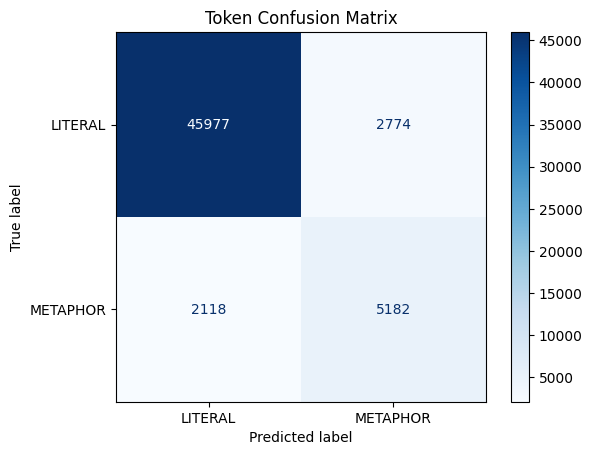

Token Metaphor Recall: 0.710
Total Metaphor Tokens: 7300


In [10]:
# Token Classifier Results (your F1=0.692)
token_test_ds = TokenDataset(test_df, tokenizer, max_len=MAX_LEN)
token_pred = trainer.predict(token_test_ds)

# Extract predictions (filter -100 padding)
token_predictions = np.argmax(token_pred.predictions, axis=2)
token_labels = token_pred.label_ids

true_labels, pred_labels = [], []
for label_row, pred_row in zip(token_labels, token_predictions):
    for l, p in zip(label_row, pred_row):
        if l != -100:
            true_labels.append(l)
            pred_labels.append(p)

print("=== TOKEN CLASSIFIER REPORT ===")
print(classification_report(true_labels, pred_labels, target_names=['LITERAL', 'METAPHOR'], digits=3))

cm = confusion_matrix(true_labels, pred_labels)
disp = ConfusionMatrixDisplay(cm, display_labels=['LITERAL', 'METAPHOR'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Token Confusion Matrix')
plt.show()

print(f"Token Metaphor Recall: {recall_score(true_labels, pred_labels, pos_label=1):.3f}")
print(f"Total Metaphor Tokens: {sum(true_labels)}")

In [12]:
# First, ensure you have the `token_test_ds`, `token_predictions`, and `token_labels` from cell L7ueuvH6wP1W

def analyze_errors(dataset, predictions, true_labels, tokenizer, num_samples=10):
    misclassified_examples = []
    for i in range(len(true_labels)):
        original_words = dataset.words[i]
        predicted_labels_row = predictions[i]
        true_labels_row = true_labels[i]

        # Filter out padding and subword tokens for original words
        aligned_true_labels = []
        aligned_pred_labels = []
        aligned_tokens = []

        encoding = tokenizer(
            original_words,
            is_split_into_words=True,
            truncation=True,
            padding='max_length',
            max_length=dataset.max_len,
            return_tensors='pt'
        )
        word_ids = encoding.word_ids()

        for j, word_id in enumerate(word_ids):
            if word_id is not None and true_labels_row[j] != -100:
                token = tokenizer.convert_ids_to_tokens(encoding['input_ids'][0, j].item())
                aligned_tokens.append(token)
                aligned_true_labels.append(true_labels_row[j])
                aligned_pred_labels.append(predicted_labels_row[j])

        for k in range(len(aligned_true_labels)):
            if aligned_true_labels[k] != aligned_pred_labels[k]:
                misclassified_examples.append({
                    'document_idx': i,
                    'token_idx_in_sentence': k,
                    'token': aligned_tokens[k],
                    'true_label': aligned_true_labels[k],
                    'predicted_label': aligned_pred_labels[k],
                    'full_sentence_words': original_words
                })

    return misclassified_examples




In [ ]:
# Run analysis
misclassified_tokens = analyze_errors(token_test_ds, token_predictions, token_labels, tokenizer)
print(f"Found {len(misclassified_tokens)} misclassified tokens.")
if misclassified_tokens:
    print("\nExample Misclassifications:")
    for i, error in enumerate(misclassified_tokens[:num_samples]):
        print(f"--- Error {i+1} ---")
        print(f"Document Index: {error['document_idx']}")
        print(f"Token: {error['token']} (True: {'METAPHOR' if error['true_label']==1 else 'LITERAL'}, Predicted: {'METAPHOR' if error['predicted_label']==1 else 'LITERAL'})")
        print(f"Sentence: {' '.join(error['full_sentence_words'])}")
print("Uncomment the code above to run the error analysis.")

In [22]:
# Removed 'del' statements for token_pred, token_predictions, token_labels to ensure they are available for error analysis
import gc
gc.collect()

94

## Stylistic Features

In [21]:
!pip install -q lexical-diversity
import lexical_diversity

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.8/117.8 kB 5.3 MB/s eta 0:00:00


In [23]:
from lexical_diversity import lex_div as ld

In [24]:
english_stopwords = set(nltk.corpus.stopwords.words('english'))
def compute_enriched_features(doc_df, pipeline_meta_tokens):
    """9 non-redundant stylistic features (added avg_sent_len)"""
    all_words = [w for sublist in doc_df['words'] for w in sublist]
    full_text = ' '.join(all_words)
    doc = nlp(full_text)

    # Calculate total subword tokens using the HuggingFace tokenizer
    # This aligns the denominator with how pipeline_meta_tokens are counted
    encoded_input = tokenizer(all_words, is_split_into_words=True, add_special_tokens=False)
    total_subword_tokens = len(encoded_input['input_ids'])

    num_meta = len([p for p in pipeline_meta_tokens if p['score'] > 0.3])

    mtld_score = ld.mtld(all_words)

    # Process sentences once to get a list and its count
    sentences = list(doc.sents)
    num_sents = len(sentences)
    sent_lengths = [len(s.text.split()) for s in sentences]

    # Calculate POS counts and total tokens for robustness
    num_nouns = sum(1 for t in doc if t.pos_ == 'NOUN')
    num_verbs = sum(1 for t in doc if t.pos_ == 'VERB')
    num_adj = sum(1 for t in doc if t.pos_ == 'ADJ')
    num_adv = sum(1 for t in doc if t.pos_ == 'ADV')
    num_content_words = num_nouns + num_verbs + num_adj + num_adv
    num_function_words = sum(1 for t in doc if t.is_stop or t.pos_ in ['ADP', 'PRT', 'CONJ'])
    num_ccomp_clauses = len([t for t in doc if t.dep_ == 'ccomp'])
    total_tokens_doc = len(doc)

    return {
        # Metaphor Core
        'meta_density': num_meta / total_subword_tokens if total_subword_tokens else 0, # Changed denominator

        # Lexical (2)
        'mtld': mtld_score,
        'type_token_ratio': len(set(w.lower() for w in all_words)) / len(all_words) if len(all_words) else 0,

        # Syntactic (3)
        'avg_sent_len': np.mean(sent_lengths) if num_sents > 0 else 0,
        'sent_len_var': np.var(sent_lengths) if num_sents > 0 else 0,

        # Semantic (2)
        'noun_verb_ratio': num_nouns / max(1, num_verbs), # Ensure no division by zero
        'content_density': num_content_words / total_tokens_doc if total_tokens_doc else 0,

        # Style (2)
        'function_ratio': num_function_words / total_tokens_doc if total_tokens_doc else 0
    }

In [25]:
def pipeline_on_test_df(df_input, sent_pipe, token_pipe, batch_size=32, sent_threshold=0.3):
    test_results = {}

    df = df_input.reset_index(drop=True)

    # Sentence predictions
    all_sentences = [' '.join(row['words']) for _, row in df.iterrows()]
    sent_preds_batch = sent_pipe(all_sentences, batch_size=batch_size, truncation=True, max_length=MAX_LEN)

    metaphorical_sentences = []
    original_sent_indices = [] # Store list index for mapping back
    for i, sent_pred_output in enumerate(sent_preds_batch):
        meta_prob = 0.0
        if isinstance(sent_pred_output, list):
            # Expected behavior with return_all_scores=True
            meta_prob = next((s['score'] for s in sent_pred_output if s['label'] == 'LABEL_1'), 0.0)
        elif isinstance(sent_pred_output, dict):
            # Fallback if return_all_scores=False was implicitly used (single top prediction)
            if sent_pred_output['label'] == 'LABEL_1':
                meta_prob = sent_pred_output['score']

        if meta_prob > sent_threshold:
            metaphorical_sentences.append(all_sentences[i])
            original_sent_indices.append(i) # Store list index 'i'

    # Token predictions on metaphorical sentences only
    # Ensure we only attempt token classification if there are metaphorical sentences
    meta_token_preds = []
    if metaphorical_sentences:
        meta_token_preds = token_pipe(metaphorical_sentences, batch_size=batch_size)

    # Initialize a list of lists for all sentences to store their token predictions
    all_sentence_token_preds = [[] for _ in range(len(all_sentences))]

    # Map token predictions back to original sentence list indices
    for filtered_idx, original_list_idx in enumerate(original_sent_indices):
        if filtered_idx < len(meta_token_preds):
            all_sentence_token_preds[original_list_idx] = meta_token_preds[filtered_idx]

    # Aggregate token predictions by document
    # The input `df` contains 'words' for each sentence.
    # We iterate through the processed dataframe to get document groups and their sentences.
    for doc_name, doc_group in df.groupby('document_name'):
        doc_meta_tokens = []
        for list_idx, row_in_doc_group in doc_group.iterrows(): # list_idx will now be the correct 0-based index
            doc_meta_tokens.extend([p for p in all_sentence_token_preds[list_idx] if p['score'] > 0.3])
        test_results[doc_name] = doc_meta_tokens

    print(f"Pipeline ready. Note: Token prediction aggregation for documents with filtered sentences now correctly mapped.")
    return test_results

print("Pipeline ready")

Pipeline ready


In [26]:
def build_stylistic_df(results, df):
    doc_features = []
    for doc_name, meta_tokens in results.items():
        doc_group = df[df['document_name'] == doc_name]
        features = compute_enriched_features(doc_group, meta_tokens)
        features['document_name'] = doc_name
        doc_features.append(features)
    return pd.DataFrame(doc_features)

## Run Pipeline on VUAMC Test

In [27]:
test_results = pipeline_on_test_df(test_df, sent_pipe, token_pipe)
print(f"VUAMC test processed: {len(test_results)} documents")

Pipeline ready. Note: Token prediction aggregation for documents with filtered sentences now correctly mapped.
VUAMC test processed: 30 documents


In [28]:
document_features = []
for doc_name, meta_tokens in test_results.items():
    doc_df_subset = test_df[test_df['document_name'] == doc_name].copy()
    features = compute_enriched_features(doc_df_subset, meta_tokens)
    features['document_name'] = doc_name
    document_features.append(features)

df_document_features = pd.DataFrame(document_features)
print(f"Computed features for {len(df_document_features)} documents.")
print(df_document_features.head())

Token indices sequence length is longer than the specified maximum sequence length for this model (523 > 512). Running this sequence through the model will result in indexing errors


Computed features for 30 documents.
   meta_density        mtld  type_token_ratio  avg_sent_len  sent_len_var  \
0      0.868526  104.684969          0.596059     25.500000    140.000000   
1      0.775862  129.430000          0.906977     43.000000      0.000000   
2      0.814532  112.352373          0.553806     29.538462    136.248521   
3      0.782341   73.836425          0.402159     26.607143    180.809949   
4      0.826087   97.537987          0.481562     28.812500    116.652344   

   noun_verb_ratio  content_density  function_ratio   document_name  
0         2.368421         0.423810        0.433333  a1f-fragment09  
1         2.000000         0.302326        0.372093  a1f-fragment12  
2         2.225806         0.375648        0.453368  a1h-fragment06  
3         1.521739         0.311081        0.412550  a1j-fragment33  
4         1.444444         0.393235        0.454545  a1j-fragment34  


In [29]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage

# Prepare data for clustering: Drop 'document_name' and highly correlated 'sent_len_var'
vuamc_features_df = df_document_features.drop(columns=['document_name', 'sent_len_var'])

scaler_vuamc = StandardScaler()
scaled_vuamc_features = scaler_vuamc.fit_transform(vuamc_features_df)

print("VUAMC test features scaled and ready for clustering.")

VUAMC test features scaled and ready for clustering.


### Hierarchical Clustering for VUAMC Test Documents

In [30]:
# Hierarchical Clustering for VUAMC test documents
hierarchical_vuamc = AgglomerativeClustering(n_clusters=3) # Starting with 3 clusters, can be adjusted
hierarchical_vuamc_labels = hierarchical_vuamc.fit_predict(scaled_vuamc_features)
df_document_features['hierarchical_cluster'] = hierarchical_vuamc_labels

# Create full_label for dendrogram
df_document_features['full_label'] = df_document_features['document_name']

# Evaluate Hierarchical Clustering
vuamc_hierarchical_silhouette = silhouette_score(scaled_vuamc_features, hierarchical_vuamc_labels)
print(f"VUAMC Hierarchical Silhouette Score (k=3): {vuamc_hierarchical_silhouette:.3f}")

print("Hierarchical clustering for VUAMC test documents complete.")

VUAMC Hierarchical Silhouette Score (k=3): 0.227
Hierarchical clustering for VUAMC test documents complete.


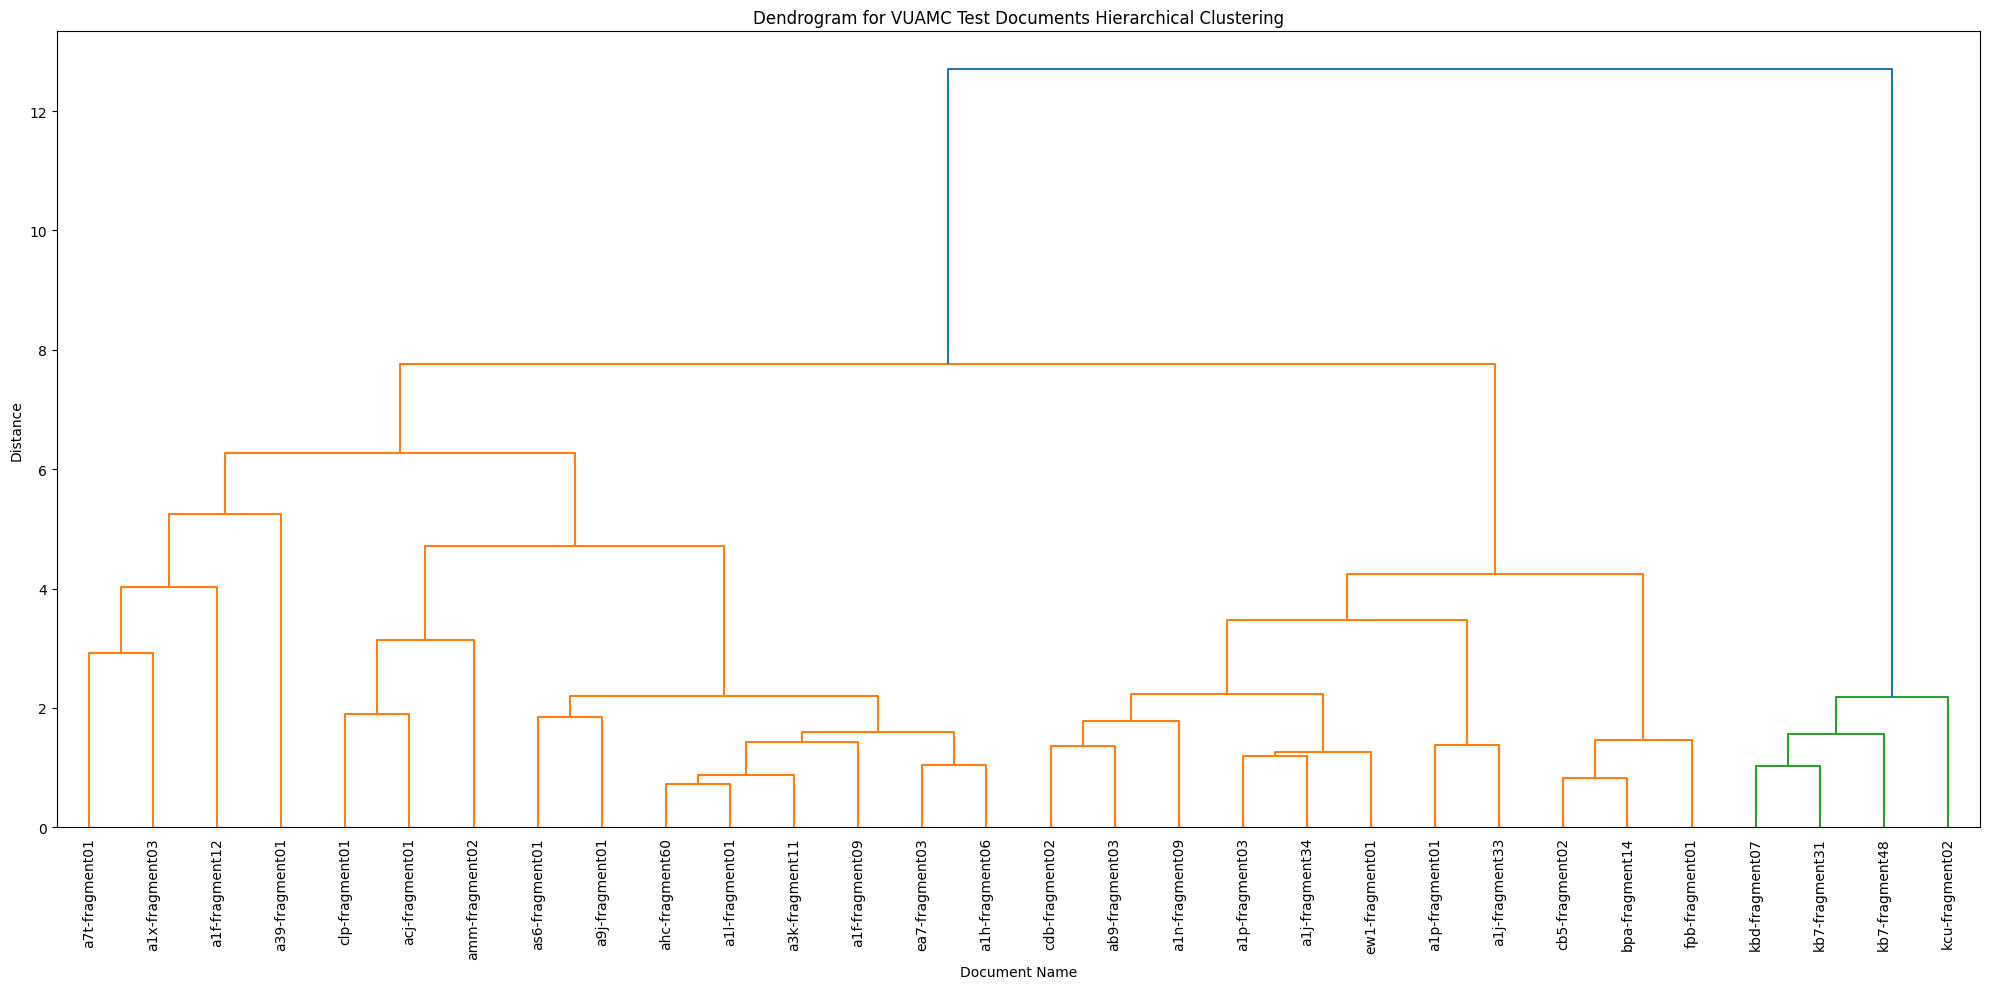

The dendrogram visualizes the hierarchical clustering for your VUAMC test documents.


In [31]:
plt.figure(figsize=(20, 10))
linked_vuamc = linkage(scaled_vuamc_features, method='ward')
dendrogram(linked_vuamc,
           orientation='top',
           distance_sort='descending',
           show_leaf_counts=False,
           labels=df_document_features['full_label'].tolist())
plt.title('Dendrogram for VUAMC Test Documents Hierarchical Clustering')
plt.xlabel('Document Name')
plt.ylabel('Distance')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

print("The dendrogram visualizes the hierarchical clustering for your VUAMC test documents.")

### Documents per Hierarchical Cluster (VUAMC Test)

In [32]:
vuamc_cluster_composition = df_document_features.groupby('hierarchical_cluster')['document_name'].apply(list).reset_index()
vuamc_cluster_composition.columns = ['Hierarchical Cluster', 'Document Names']
display(vuamc_cluster_composition)
print("This table shows which VUAMC test documents are assigned to each hierarchical cluster.")

,Hierarchical Cluster,Document Names
0,0,"[a1f-fragment09, a1f-fragment12, a1h-fragment0..."
1,1,"[kb7-fragment31, kb7-fragment48, kbd-fragment0..."
2,2,"[a1j-fragment33, a1j-fragment34, a1n-fragment0..."


This table shows which VUAMC test documents are assigned to each hierarchical cluster.


# Run Pipeline on Authors Dataset

In [33]:
authors_results = pipeline_on_test_df(test_df_raw.sample(4000), sent_pipe, token_pipe)  # Sample for speed
print(f"Authors processed: {len(authors_results)} documents")

Pipeline ready. Note: Token prediction aggregation for documents with filtered sentences now correctly mapped.
Authors processed: 80 documents


## Build stylistic df

In [34]:


authors_stylistics = build_stylistic_df(authors_results, test_df_raw)


In [35]:
authors_stylistics.head()

,meta_density,mtld,type_token_ratio,avg_sent_len,sent_len_var,noun_verb_ratio,content_density,function_ratio,document_name
0,0.474978,134.791738,0.374068,91.736842,7614.193906,1.198413,0.421687,0.586345,A Study in Scarlet
1,0.411239,113.220153,0.385728,61.000000,2982.647059,1.816239,0.437801,0.586307,An Unsocial Socialist
2,0.392291,98.755141,0.332229,68.971429,10756.599184,1.054496,0.426678,0.577051,Anna Karenina
3,0.419945,112.822404,0.383618,66.517241,4964.318668,1.714286,0.444902,0.558187,Burning Daylight
4,0.291934,99.752355,0.416752,61.187500,3065.277344,1.507937,0.396761,0.529352,Caesar and Cleopatra


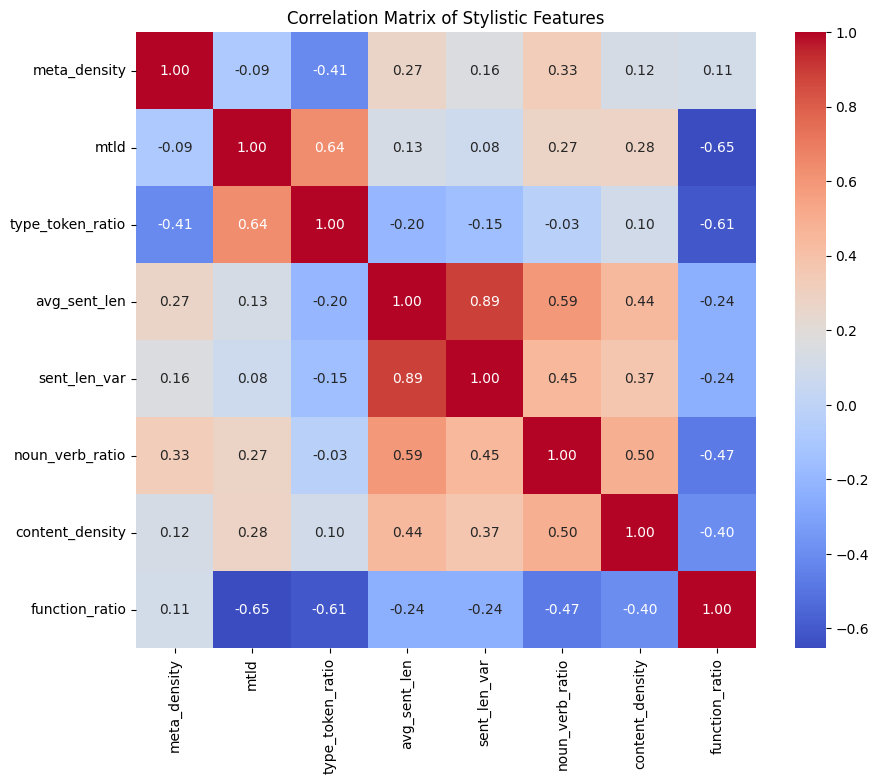

In [36]:
# plot correlation matrix
# Exclude 'document_name' column as it is not numeric for correlation calculation
corr_matrix = authors_stylistics.drop(columns=['document_name']).corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Stylistic Features')
plt.show()

## Clustering

In [37]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for clustering: Drop 'document_name' and highly correlated 'sent_len_var'
features_df = authors_stylistics.drop(columns=['document_name', 'sent_len_var'])

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features_df)

print("Features scaled and ready for clustering.")

Features scaled and ready for clustering.


### Dendrogram for Hierarchical Clustering

In [38]:
from scipy.cluster.hierarchy import dendrogram, linkage

# Hierarchical Clustering
hierarchical = AgglomerativeClustering(n_clusters=3) # Using 3 clusters for comparison
hierarchical_labels = hierarchical.fit_predict(scaled_features)
authors_stylistics['hierarchical_cluster'] = hierarchical_labels

# Get unique document_name and author mapping from test_df_raw
author_map = test_df_raw[['document_name', 'author']].drop_duplicates()

# Create authors_stylistics_with_author after clustering, ensuring it has hierarchical_cluster
authors_stylistics_with_author = authors_stylistics.merge(author_map, on='document_name', how='left')
authors_stylistics_with_author['full_label'] = authors_stylistics_with_author['document_name'] + ' (' + authors_stylistics_with_author['author'] + ')'

# Evaluate Hierarchical Clustering
hierarchical_silhouette = silhouette_score(scaled_features, hierarchical_labels)
print(f"Hierarchical Silhouette Score (k=3): {hierarchical_silhouette:.3f}")

print("Hierarchical clustering complete.")

Hierarchical Silhouette Score (k=3): 0.177
Hierarchical clustering complete.


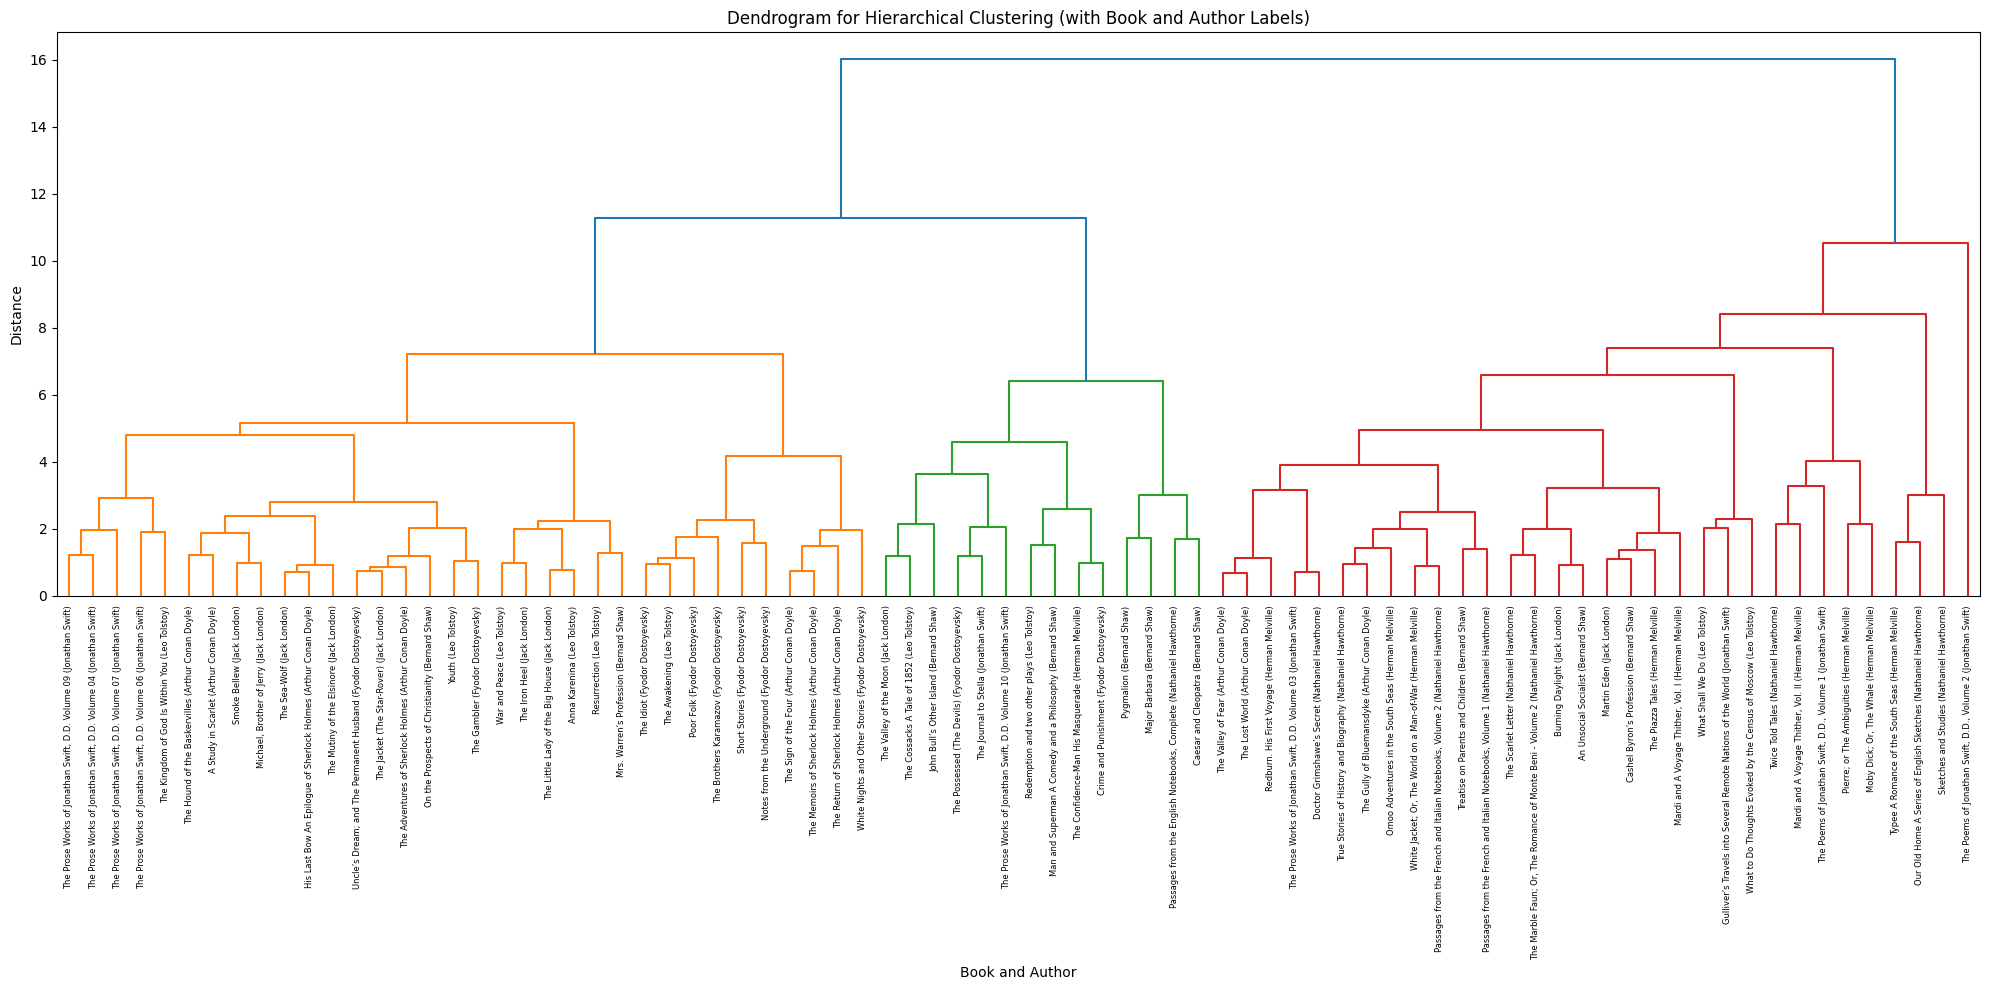

The dendrogram now visually represents the hierarchical clustering process with book and author names as labels. You can identify clusters by drawing a horizontal line across the dendrogram at a chosen distance, and the vertical lines it crosses represent the clusters.


In [39]:
from scipy.cluster.hierarchy import dendrogram, linkage

plt.figure(figsize=(20, 10)) # Increased figure size for better readability of labels
linked = linkage(scaled_features, method='ward') # 'ward' minimizes the variance of the clusters being merged
dendrogram(linked,
           orientation='top',
           distance_sort='descending',
           show_leaf_counts=False, # Set to False to prevent overlapping with custom labels
           labels=authors_stylistics_with_author['full_label'].tolist())
plt.title('Dendrogram for Hierarchical Clustering (with Book and Author Labels)')
plt.xlabel('Book and Author')
plt.ylabel('Distance')
plt.xticks(rotation=90) # Rotate labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

print("The dendrogram now visually represents the hierarchical clustering process with book and author names as labels. You can identify clusters by drawing a horizontal line across the dendrogram at a chosen distance, and the vertical lines it crosses represent the clusters.")

### Books per Hierarchical Cluster

In [40]:
cluster_author_composition = authors_stylistics_with_author.groupby(['hierarchical_cluster', 'author']).size().unstack(fill_value=0)
display(cluster_author_composition)
print("This table shows how many books from each author are assigned to each hierarchical cluster.")

author,Arthur Conan Doyle,Bernard Shaw,Fyodor Dostoyevsky,Herman Melville,Jack London,Jonathan Swift,Leo Tolstoy,Nathaniel Hawthorne
hierarchical_cluster,,,,,,,,
0,3,3,0,9,2,4,2,9
1,7,2,8,0,7,4,6,0
2,0,5,2,1,1,2,2,1


This table shows how many books from each author are assigned to each hierarchical cluster.


### Characterizing Clusters by Feature Means

In [42]:
cluster_books = authors_stylistics_with_author.groupby('hierarchical_cluster')['full_label'].apply(list).reset_index()
cluster_books.columns = ['Hierarchical Cluster', 'Books (with Authors)']
display(cluster_books)
print("This table lists all books and their authors within each hierarchical cluster.")

,Hierarchical Cluster,Books (with Authors)
0,0,"[An Unsocial Socialist (Bernard Shaw), Burning..."
1,1,"[A Study in Scarlet (Arthur Conan Doyle), Anna..."
2,2,"[Caesar and Cleopatra (Bernard Shaw), Crime an..."


This table lists all books and their authors within each hierarchical cluster.


### Feature Importance for Hierarchical Clustering

To identify which stylistic features are most influential in forming the hierarchical clusters, we can train a classifier using the scaled features to predict the assigned cluster labels. The feature importances from this classifier can then highlight the distinguishing characteristics of the clusters.

,feature,importance
0,content_density,0.227149
1,noun_verb_ratio,0.154414
2,type_token_ratio,0.152924
3,mtld,0.141394
4,meta_density,0.139407
5,avg_sent_len,0.117771
6,function_ratio,0.066941


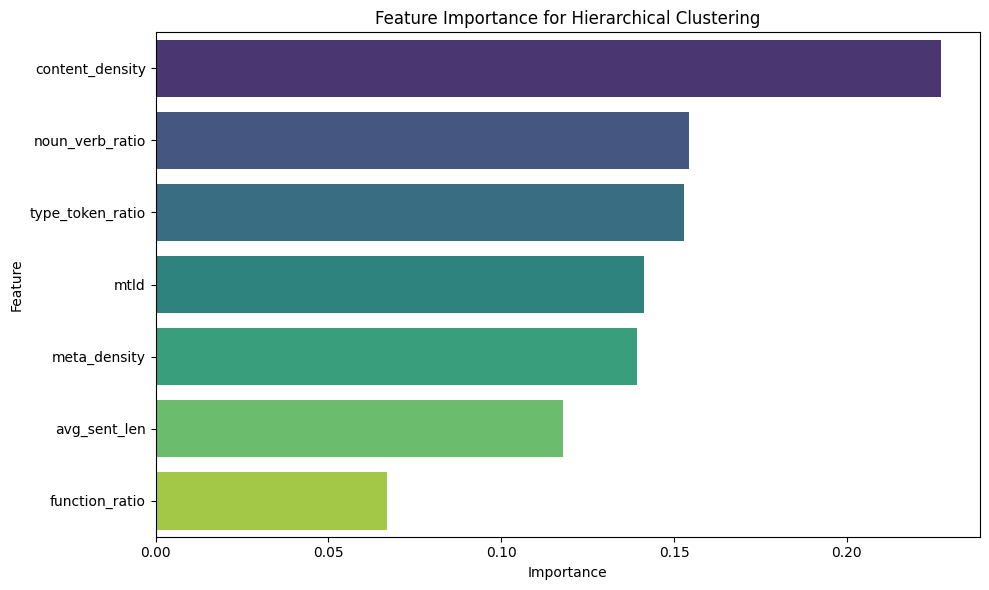

Feature importance analysis complete. The plot and table above show which features were most influential in determining the hierarchical clusters.


In [55]:
from sklearn.ensemble import RandomForestClassifier

# Prepare data for feature importance analysis
X = scaled_features # Already scaled features from authors_stylistics
y = hierarchical_labels # Hierarchical cluster labels

# Train a RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=SEED)
rf_model.fit(X, y)

# Get feature importances
feature_importances = rf_model.feature_importances_

# Map importances to feature names
feature_names = features_df.columns # Get feature names from the original (non-dropped) features_df
importance_df = pd.DataFrame({'feature': feature_names, 'importance': feature_importances})
importance_df = importance_df.sort_values(by='importance', ascending=False).reset_index(drop=True)

display(importance_df)

# Plot feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=importance_df, palette='viridis')
plt.title('Feature Importance for Hierarchical Clustering')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print("Feature importance analysis complete. The plot and table above show which features were most influential in determining the hierarchical clusters.")

Melville/Hawthorne anchor narrative cluster; Doyle/Tolstoy dominate fiction; Swift pulls essays/satire — aligns with stylistic metaphors .

# Run on Narra_Detect

In [43]:
# Load NarraDetect dataset
NARRA_DETECT_URL = "https://raw.githubusercontent.com/Dona134/Metaphor-Classification-NLP/main/data/processed/NarraDetect.csv"

df_narradetect_raw = pd.read_csv(NARRA_DETECT_URL)
df_narradetect_raw['words'] = df_narradetect_raw['words'].apply(ast.literal_eval)
df_narradetect_raw['token_labels'] = df_narradetect_raw['words'].apply(lambda x: [0]*len(x))  # Placeholder
df_narradetect_raw['sentence_label'] = 0 # Placeholder
print(f"NarraDetect: {len(df_narradetect_raw)} rows")

# Run the pipeline on NarraDetect data
narradetect_results = pipeline_on_test_df(df_narradetect_raw, sent_pipe, token_pipe)
print(f"NarraDetect processed: {len(narradetect_results)} documents")

NarraDetect: 19278 rows
Pipeline ready. Note: Token prediction aggregation for documents with filtered sentences now correctly mapped.
NarraDetect processed: 18 documents


In [44]:
# Build stylistic DataFrame for NarraDetect
narradetect_stylistics = build_stylistic_df(narradetect_results, df_narradetect_raw)

# Add a placeholder 'author' column if it doesn't exist, to prevent errors in subsequent steps
if 'author' not in narradetect_stylistics.columns:
    # Assuming document_name is unique for each 'book' or 'text' in NarraDetect
    # If NarraDetect doesn't have an 'author' column, we can create a dummy one or use document_name
    narradetect_stylistics['author'] = narradetect_stylistics['document_name'].apply(lambda x: 'Author_of_' + str(x).split('-')[0]) # Example dummy author

display(narradetect_stylistics.head())

,meta_density,mtld,type_token_ratio,avg_sent_len,sent_len_var,noun_verb_ratio,content_density,function_ratio,document_name,author
0,0.287379,228.527417,0.253294,148.449367,23185.032246,2.717842,0.557614,0.392693,ABSTRACT,Author_of_ABSTRACT
1,0.793987,129.282627,0.185293,191.656250,32352.788086,1.954016,0.462625,0.574929,APHORISM,Author_of_APHORISM
2,0.777970,216.707604,0.250835,91.513208,8737.110203,1.495441,0.417625,0.514365,BIO,Author_of_BIO
3,0.786838,221.945503,0.225479,171.079439,30221.232007,1.926471,0.483846,0.471557,BREVIEW,Author_of_BREVIEW
4,0.810129,132.314795,0.145496,184.304965,32769.474373,1.022157,0.413964,0.597038,FABLE,Author_of_FABLE


In [45]:
# Prepare data for clustering: Drop 'document_name', 'author', and highly correlated 'sent_len_var'
narradetect_features_df = narradetect_stylistics.drop(columns=['document_name', 'author', 'sent_len_var'])

scaler_narradetect = StandardScaler()
scaled_narradetect_features = scaler_narradetect.fit_transform(narradetect_features_df)

print("NarraDetect features scaled and ready for clustering.")

NarraDetect features scaled and ready for clustering.


### Dendrogram for NarraDetect Hierarchical Clustering

NarraDetect Hierarchical Silhouette Score (k=3): 0.211


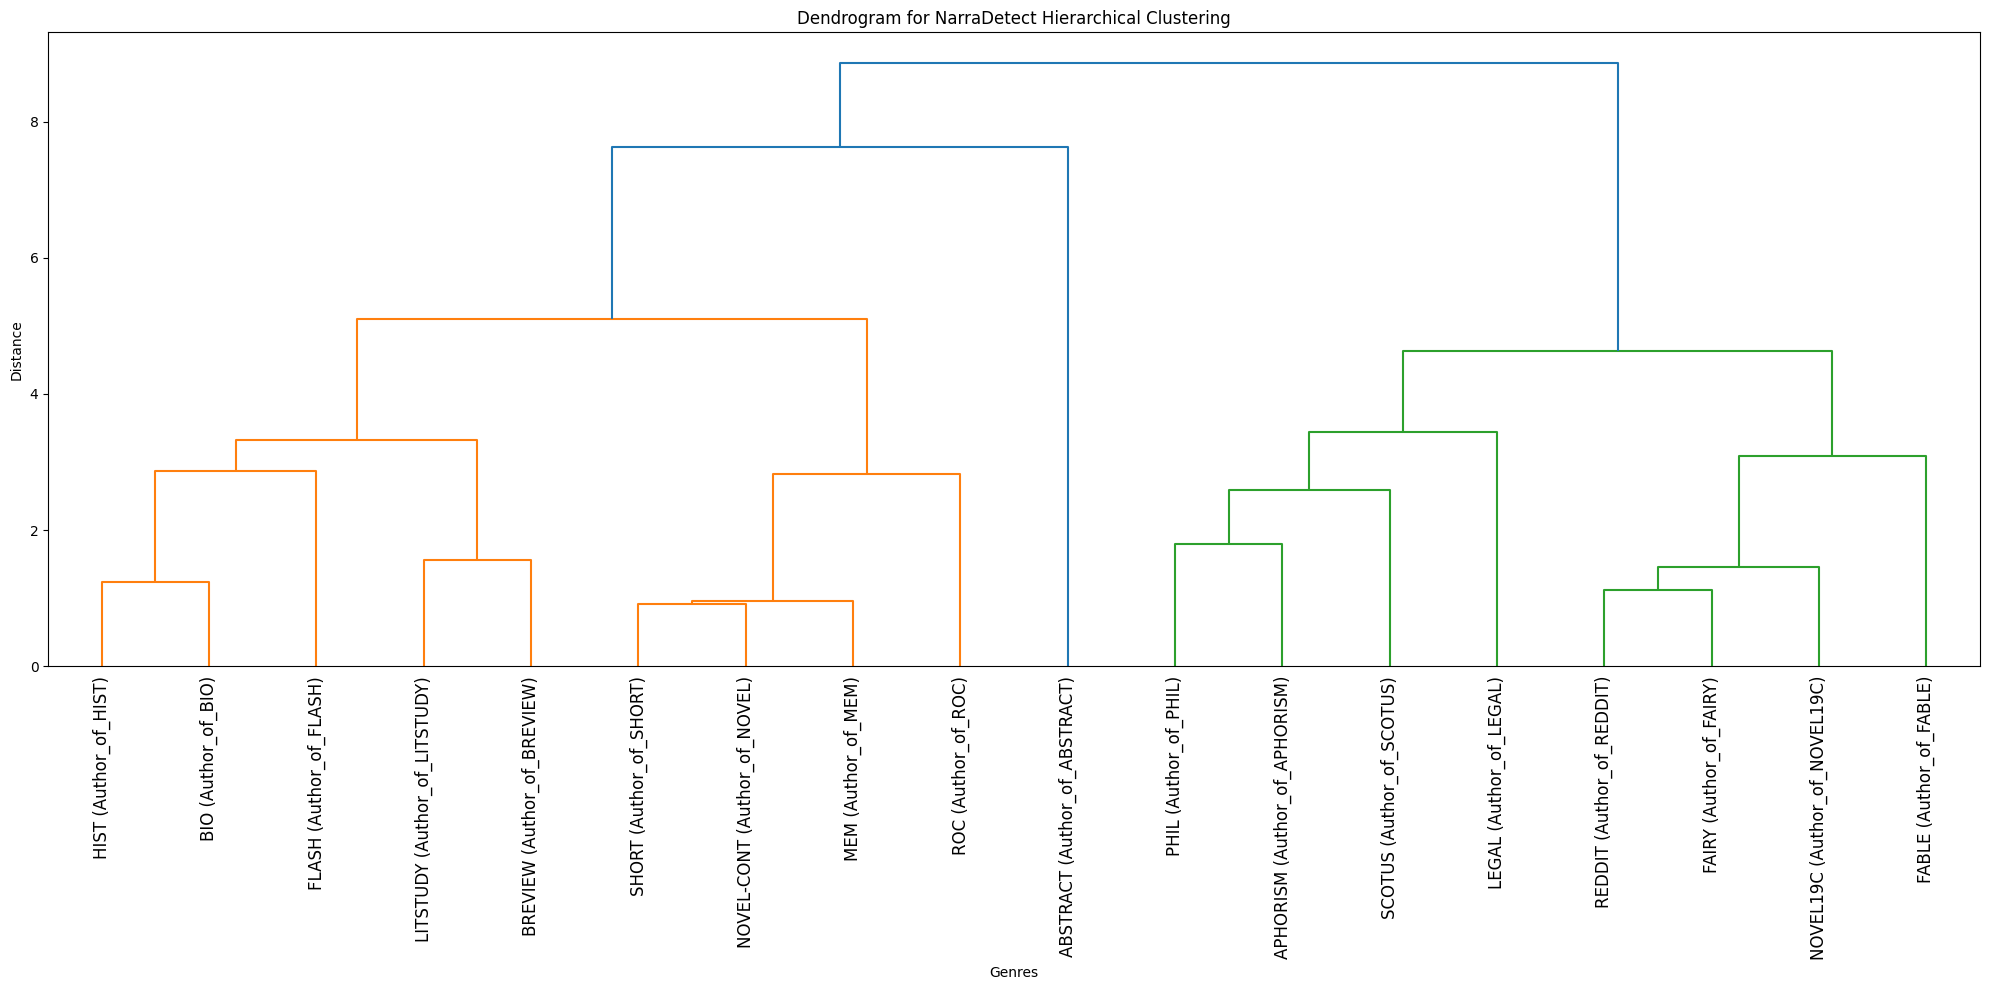

NarraDetect Hierarchical clustering complete and dendrogram displayed.


In [46]:
# Hierarchical Clustering for NarraDetect
hierarchical_narradetect = AgglomerativeClustering(n_clusters=4) # Using 3 clusters for comparison
hierarchical_narradetect_labels = hierarchical_narradetect.fit_predict(scaled_narradetect_features)
narradetect_stylistics['hierarchical_cluster'] = hierarchical_narradetect_labels

# Create narradetect_stylistics_with_author for dendrogram labels
narradetect_stylistics_with_genres = narradetect_stylistics.copy()
narradetect_stylistics_with_genres['full_label'] = narradetect_stylistics_with_genres['document_name'] + ' (' + narradetect_stylistics_with_genres['author'] + ')'

# Evaluate Hierarchical Clustering
narradetect_hierarchical_silhouette = silhouette_score(scaled_narradetect_features, hierarchical_narradetect_labels)
print(f"NarraDetect Hierarchical Silhouette Score (k=3): {narradetect_hierarchical_silhouette:.3f}")

plt.figure(figsize=(20, 10)) # Increased figure size for better readability of labels
linked_narradetect = linkage(scaled_narradetect_features, method='ward') # 'ward' minimizes the variance of the clusters being merged
dendrogram(linked_narradetect,
           orientation='top',
           distance_sort='descending',
           show_leaf_counts=False, # Set to False to prevent overlapping with custom labels
           labels=narradetect_stylistics_with_genres['full_label'].tolist())
plt.title('Dendrogram for NarraDetect Hierarchical Clustering')
plt.xlabel('Genres')
plt.ylabel('Distance')
plt.xticks(rotation=90) # Rotate labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

print("NarraDetect Hierarchical clustering complete and dendrogram displayed.")

In [47]:
narradetect_cluster_books = narradetect_stylistics_with_genres.groupby('hierarchical_cluster')['full_label'].apply(list).reset_index()
narradetect_cluster_books.columns = ['Hierarchical Cluster', 'Genres']
display(narradetect_cluster_books)
print("This table lists all books and their authors within each hierarchical cluster for NarraDetect.")

,Hierarchical Cluster,Genres
0,0,"[APHORISM (Author_of_APHORISM), FABLE (Author_..."
1,1,"[BIO (Author_of_BIO), BREVIEW (Author_of_BREVI..."
2,2,[ABSTRACT (Author_of_ABSTRACT)]
3,3,"[MEM (Author_of_MEM), NOVEL-CONT (Author_of_NO..."


This table lists all books and their authors within each hierarchical cluster for NarraDetect.


### Feature Importance for NarraDetect Hierarchical Clustering

Similar to the Authors dataset, we will analyze feature importance for NarraDetect to identify which stylistic features are most influential in forming its hierarchical clusters.

,feature,importance
0,mtld,0.243510
1,type_token_ratio,0.219341
2,function_ratio,0.153485
3,noun_verb_ratio,0.122766
4,meta_density,0.122303
5,avg_sent_len,0.086862
6,content_density,0.051734


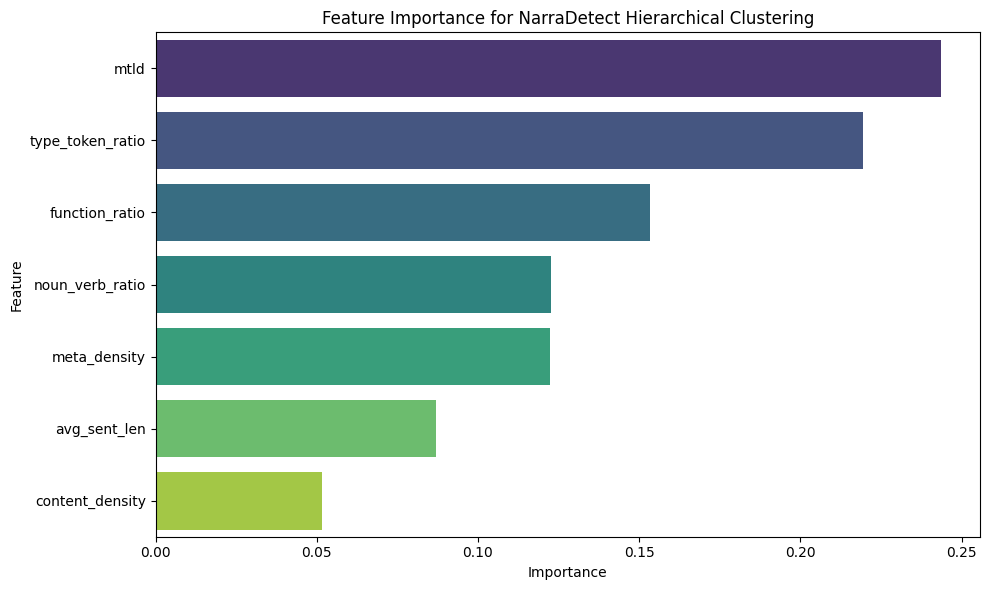

Feature importance analysis for NarraDetect complete. The plot and table above show which features were most influential in determining the hierarchical clusters.


In [56]:
from sklearn.ensemble import RandomForestClassifier

# Prepare data for feature importance analysis for NarraDetect
X_narradetect = scaled_narradetect_features # Scaled features from narradetect_stylistics
y_narradetect = hierarchical_narradetect_labels # Hierarchical cluster labels for NarraDetect

# Train a RandomForestClassifier
rf_model_narradetect = RandomForestClassifier(n_estimators=100, random_state=SEED)
rf_model_narradetect.fit(X_narradetect, y_narradetect)

# Get feature importances
feature_importances_narradetect = rf_model_narradetect.feature_importances_

# Map importances to feature names
feature_names_narradetect = narradetect_features_df.columns
importance_df_narradetect = pd.DataFrame({'feature': feature_names_narradetect, 'importance': feature_importances_narradetect})
importance_df_narradetect = importance_df_narradetect.sort_values(by='importance', ascending=False).reset_index(drop=True)

display(importance_df_narradetect)

# Plot feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=importance_df_narradetect, palette='viridis')
plt.title('Feature Importance for NarraDetect Hierarchical Clustering')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print("Feature importance analysis for NarraDetect complete. The plot and table above show which features were most influential in determining the hierarchical clusters.")

# Future work


### 1. Advanced Model Training: Hyperparameter Tuning and Cross-Validation

Instead of fixed training parameters, we can implement a more robust training strategy using hyperparameter tuning (e.g., with `Optuna` or `Ray Tune`) and k-fold cross-validation. This will lead to more reliable model performance estimates and potentially better-performing models.

(keeps crashing)

In [48]:
# # !pip install -q optuna
# import optuna
# from transformers import TrainingArguments, Trainer
# from sklearn.model_selection import KFold
# import numpy as np

# def model_init():
#     return AutoModelForTokenClassification.from_pretrained("roberta-base", num_labels=2)

# def compute_metrics_wrapper(eval_pred):
#     # Re-use your existing compute_metrics_fn
#     return compute_metrics_fn(eval_pred)

# def objective(trial):
#     # Suggest hyperparameters
#     learning_rate = trial.suggest_float("learning_rate", 1e-5, 5e-5, log=True)
#     per_device_train_batch_size = trial.suggest_categorical("per_device_train_batch_size", [8, 16, 32])
#     num_train_epochs = trial.suggest_int("num_train_epochs", 2, 5)

#     training_args = TrainingArguments(
#         output_dir=f"./token_model_tuned_{trial.number}",
#         per_device_train_batch_size=per_device_train_batch_size,
#         num_train_epochs=num_train_epochs,
#         eval_strategy="epoch",
#         save_strategy="epoch",
#         fp16=False, # Set to True if your GPU supports it
#         load_best_model_at_end=True,
#         metric_for_best_model="f1",
#         learning_rate=learning_rate,
#         seed=SEED,
#         # disable_tqdm=True # Optional, to reduce logging verbosity during trials
#     )

#     # Use a subset of the data for faster tuning, or full data for more thorough search
#     # For a real thesis, you might want to use k-fold cross-validation within Optuna or separately.
#     trainer = CustomTokenTrainer(
#         model_init=model_init,
#         args=training_args,
#         train_dataset=token_train,
#         eval_dataset=token_val,
#         class_weights=BEST_EN_WEIGHTS,
#         compute_metrics=compute_metrics_wrapper,
#         callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
#     )
#     trainer.train()

#     eval_results = trainer.evaluate()
#     return eval_results["eval_f1"]

# # Note: This can take a very long time depending on the number of trials and data size.
# study = optuna.create_study(direction="maximize")
# study.optimize(objective, n_trials=5) # Start with a small number of trials

# print("Best trial:", study.best_trial.params)
# print("Best F1 score:", study.best_value)

# print("Code for Optuna hyperparameter tuning for token classification model. Uncomment and run to execute.")
# print("For cross-validation, you would typically integrate KFold split logic here or around the Trainer.")


### 3. More Advanced Feature Engineering (Beyond Stylistic Features)

These might require more complex NLP pipelines but can capture deeper insights.

Examples include:
*   **Syntactic Features**: Dependency parse patterns related to metaphor (e.g., subject-verb-object relationships involving abstract/concrete words).
*   **Semantic Features**: Word embeddings (e.g., word2vec, GloVe, FastText) or contextual embeddings (from BERT, RoBERTa) to capture semantic similarity and distance between words. You could calculate vector differences between target words and their typical contexts.
*   **Discourse Features**: Features that capture how metaphors are used across sentences or within larger textual units.
*   **Lexical Semantic Resources**: Integrating knowledge from resources like WordNet (synonyms, hypernyms, hyponyms) or ConceptNet.



In [49]:
from transformers import AutoModel

# Load a pre-trained model to extract contextual embeddings (e.g., roberta-base)
# model_for_embeddings = AutoModel.from_pretrained("roberta-base")

def get_contextual_embeddings(text_list, tokenizer, model, device='cpu'):
    model.to(device)
    model.eval()
    embeddings = []
    for text in text_list:
        encoded_input = tokenizer(text, return_tensors='pt', truncation=True, padding=True, max_length=MAX_LEN).to(device)
        with torch.no_grad():
            model_output = model(**encoded_input)
        # Use the mean of the last hidden states for a sentence embedding
        sentence_embedding = model_output.last_hidden_state.mean(dim=1).squeeze().cpu().numpy()
        embeddings.append(sentence_embedding)
    return np.array(embeddings)

# Example usage (uncomment to run)
# sample_sentences = [' '.join(r['words']) for _, r in train_df.sample(5).iterrows()]
# tokenizer = AutoTokenizer.from_pretrained("roberta-base")
# model_for_embeddings = AutoModel.from_pretrained("roberta-base")
# sentence_embeddings = get_contextual_embeddings(sample_sentences, tokenizer, model_for_embeddings)
# print("Shape of sample sentence embeddings:", sentence_embeddings.shape)

# You could then add these embeddings as features to your clustering input or use them in other downstream tasks.
print("Code for extracting contextual embeddings from a pre-trained model. This could be integrated into feature engineering.")


Code for extracting contextual embeddings from a pre-trained model. This could be integrated into feature engineering.


In [54]:
from sklearn.decomposition import PCA
from transformers import AutoModel

# Load a pre-trained model to extract contextual embeddings (e.g., roberta-base)
model_for_embeddings = AutoModel.from_pretrained("roberta-base")

# Generate some sample sentence embeddings to fit PCA
# We'll use a sample from the training data for this
sample_sentences_for_pca = [' '.join(r['words']) for _, r in train_df.sample(200, random_state=SEED).iterrows()]
sample_embeddings = get_contextual_embeddings(sample_sentences_for_pca, tokenizer, model_for_embeddings)

# Initialize and fit PCA
# Let's target 5 components for demonstration, adjust NUM_PCA_COMPONENTS as needed
NUM_PCA_COMPONENTS = 5 # You can experiment with this number
pca_embeddings = PCA(n_components=NUM_PCA_COMPONENTS, random_state=SEED)
pca_embeddings.fit(sample_embeddings)
print(f"PCA fitted on sample embeddings with {NUM_PCA_COMPONENTS} components.")

# Ensure that the compute_enriched_features function (cell z5T6x1EA5C0Q) and build_stylistic_df (cell sbr48RkvWwNx) are re-run
# after this cell, as they now depend on `pca_embeddings`.

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


KeyboardInterrupt: 

### 4. Exploring Alternative Clustering Algorithms and Evaluating Cluster Quality

Beyond K-Means and Agglomerative, you could explore other clustering methods like DBSCAN (density-based spatial clustering of applications with noise), Spectral Clustering, or Gaussian Mixture Models. Each has different assumptions and might reveal different structures in your data. Also, use more metrics to evaluate cluster quality.

Here's an example using DBSCAN:

In [50]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

# DBSCAN does not require the number of clusters as input, but rather two parameters: eps and min_samples.
# Finding optimal parameters can be tricky, often involves visual inspection (k-distance graph) or grid search.

# Step 1: Determine optimal `eps` using k-distance graph (for a small number of samples)
# neighbors = NearestNeighbors(n_neighbors=2)
# neighbors_fit = neighbors.fit(scaled_features) # Use scaled_features from authors_stylistics
# distances, indices = neighbors_fit.kneighbors(scaled_features)
# distances = np.sort(distances[:, 1], axis=0)

# plt.figure(figsize=(10, 6))
# plt.plot(distances)
# plt.title('K-distance graph for DBSCAN')
# plt.xlabel('Points sorted by distance')
# plt.ylabel('Epsilon (distance)')
# plt.show()

# Based on the graph, choose an 'elbow' point for eps.
# For demonstration, let's pick some arbitrary values. You'd tune these.
eps_value = 0.5 # Example value, needs tuning
min_samples_value = 3 # Example value, needs tuning

# DBSCAN Clustering
dbscan = DBSCAN(eps=eps_value, min_samples=min_samples_value)
dbscan_labels = dbscan.fit_predict(scaled_features)

authors_stylistics['dbscan_cluster'] = dbscan_labels

# DBSCAN can identify noise points, labeled as -1
num_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
print(f"DBSCAN found {num_clusters_dbscan} clusters and {sum(dbscan_labels == -1)} noise points.")

# Evaluate DBSCAN (Silhouette score might not be ideal if many noise points)
if num_clusters_dbscan > 1 and sum(dbscan_labels != -1) > 1:
    # Only calculate silhouette for non-noise points
    core_samples_mask = (dbscan_labels != -1)
    dbscan_silhouette = silhouette_score(scaled_features[core_samples_mask], dbscan_labels[core_samples_mask])
    print(f"DBSCAN Silhouette Score (eps={eps_value}, min_samples={min_samples_value}): {dbscan_silhouette:.3f}")
else:
    print("Cannot calculate Silhouette Score for DBSCAN (too few clusters or all noise).")

print("Code for DBSCAN clustering. Uncomment and tune parameters for specific datasets.")


DBSCAN found 0 clusters and 80 noise points.
Cannot calculate Silhouette Score for DBSCAN (too few clusters or all noise).
Code for DBSCAN clustering. Uncomment and tune parameters for specific datasets.
